# Scaling relations → a controlled feedback experiment on fixed halos

We use BIND2 — a **field-level** emulator that paints baryons onto
dark-matter-only maps — to do something neither a single hydro simulation nor
an analytic model can: take **one fixed set of dark-matter halos** and re-paint
their baryons under many different feedback parameter sets, then follow the
response all the way from individual-halo gas content up to the **box matter
power spectrum**.

Two methodological pillars run through everything below:

1. **The same halos.** All results use the *same* 1111 CV halos
   (log M₂₀₀c ≥ 13, from the 26 usable CAMELS-CV boxes).
   Cosmology and the initial conditions are held fixed, so when we vary feedback
   the halo population — and its cosmic variance — is *differenced away*. What
   changes is purely the baryonic response.
2. **A field-level emulator.** Because BIND2 generates *maps*, we can paste the
   re-painted halo patches back into the full 50 Mpc/h box and measure
   P_BIND(k)/P_DMO(k) — closing the loop from per-halo physics to the
   cosmological observable that weak lensing cares about.

**The argument, in four acts:**

| Act | Figures | Claim |
|-----|---------|-------|
| **I — Fidelity** | 1, 2 | BIND2 reproduces the baryonic scaling relations *and their scatter*, not just the means. |
| **II — Structured scatter** | 3 | At fixed mass the scatter is correlated across relations — there are persistent **gas-rich / gas-poor** populations. |
| **III — Controlled experiment** | 4, 5 | Re-painting the *same* halos across a 256-point Sobol design in the 30 feedback knobs shows which knobs move each population and open/close the gap between them. |
| **IV — Power spectrum** | 6, 7 | Pasting back gives the box P(k) suppression; the *same* feedback knobs drive both the per-halo gas content and the box suppression, and a single population observable (mean halo f_gas) predicts it. |

Figure 1 uses the `fm_two_head` checkpoint; the CV scaling fits (Figs 2–3)
use `fm_two_head_no_pmm`. Acts III–IV classify halos on the CV **truth** maps
(model-independent) and track them through the precomputed BIND2 Sobol cube on
ceph (`sobol_ss_cv/`).


## Setup

Imports, paths, suite metadata, geometry constants, and a small set of shared
geometric/physics helpers used by all three figures.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic

try:
    import scienceplots  # noqa: F401
    plt.style.use(['science', 'notebook'])
except ImportError:
    pass

sys.path.insert(0, '/mnt/home/mlee1/vdm_bind2')

plt.rcParams.update({
    'font.size':       10,
    'font.family':     'serif',
    'mathtext.fontset': 'cm',
    'figure.dpi':      120,
    'savefig.dpi':     300,
    'savefig.bbox':    'tight',
    'axes.grid':       False,
})

# ── paths & geometry ──────────────────────────────────────────────────────
SUITE_ROOT  = Path('/mnt/home/mlee1/ceph/fm_testsuite')
SNAP        = 'snap_090'
MASS_TAG    = 'mass_threshold_1p000e13'
MODEL_OBS   = 'fm_two_head'         # used for the obs cache (figure 1)
MODEL_CV    = 'fm_two_head_no_pmm'  # used for CV scaling fits (figures 2–3)

BOX_SIZE    = 50.0     # Mpc/h
N_PIX_FULL  = 1024
PATCH_PIX   = 128
PATCH_BOX   = BOX_SIZE * PATCH_PIX / N_PIX_FULL          # 6.25 Mpc/h
MPC_PER_PIX = PATCH_BOX / PATCH_PIX
KPC_PER_PIX = MPC_PER_PIX * 1e3                          # ≈ 48.83 kpc/h
N_PARAMS    = 35

FIG_DIR   = Path('paper_figures'); FIG_DIR.mkdir(exist_ok=True)
CACHE_DIR = Path('analysis_physics_cache'); CACHE_DIR.mkdir(exist_ok=True)

# ── suite style ───────────────────────────────────────────────────────────
SUITES        = ('CV', '1P', 'Test')
SUITE_COLORS  = {'CV': 'tab:green', '1P': 'tab:blue', 'Test': 'tab:red'}
SUITE_DISPLAY = {'CV': 'CV', '1P': '1P', 'Test': 'SB35'}

# ── observables stored in the cache ───────────────────────────────────────
OBS_KEYS = [
    'M_dm', 'M_gas', 'M_star',
    'f_b', 'f_b_norm',
    'Rc_over_R200',
    'q_DM', 'q_gas', 'q_star',
    'dq_DM',
    'Sigma_gas_c',
]

# ── shared geometry helpers ───────────────────────────────────────────────
RHO_CRIT          = 2.775e11   # M_sun/h per (Mpc/h)^3
CLOSURE_THRESHOLD = 0.90
_NB               = 32

_yy, _xx = (np.mgrid[:PATCH_PIX, :PATCH_PIX]
            - np.array([PATCH_PIX / 2, PATCH_PIX / 2])[:, None, None])
_RR_PIX        = np.sqrt(_xx ** 2 + _yy ** 2)
_BIN_EDGES_PIX = np.linspace(0, PATCH_PIX / 2, _NB + 1)
_R_CENTRES_PIX = 0.5 * (_BIN_EDGES_PIX[:-1] + _BIN_EDGES_PIX[1:])
_BIN_MASKS     = [(_RR_PIX >= _BIN_EDGES_PIX[k]) & (_RR_PIX < _BIN_EDGES_PIX[k + 1])
                  for k in range(_NB)]
_N_PIX_PER_BIN = np.array([m.sum() for m in _BIN_MASKS], dtype=np.float64)


def centers_to_pixels(centers_mpc):
    """Convert halo centres in Mpc/h to wrapped full-box pixel indices."""
    ppm = N_PIX_FULL / BOX_SIZE
    return (np.asarray(centers_mpc) * ppm).astype(np.int64) % N_PIX_FULL


def extract_patch(field_2d, cx, cy, size=PATCH_PIX):
    """Extract a size×size periodic patch from a 2D full-box map."""
    n    = field_2d.shape[0]
    half = size // 2
    ix   = (cx - half + np.arange(size)) % n
    iy   = (cy - half + np.arange(size)) % n
    return field_2d[np.ix_(ix, iy)]


def aperture_sum(patch_2d, r_pix):
    """Positive-clipped circular aperture sum (used by the observables cache)."""
    return float(np.maximum(patch_2d, 0.0)[_RR_PIX < r_pix].sum())


def aperture_sum_raw(patch_2d, r_pix):
    """Raw (unclipped, inclusive-disk) aperture sum used by the CV scaling fits."""
    return float(patch_2d[_RR_PIX <= r_pix].sum())


def r200c_pix(m200c_msunh):
    """R200c in patch pixels from halo mass [M_sun/h]."""
    r_mpc = (3.0 * m200c_msunh / (4.0 * np.pi * 200.0 * RHO_CRIT)) ** (1.0 / 3.0)
    return r_mpc / MPC_PER_PIX


def save_fig(fig, name, ext=('pdf', 'png')):
    for e in ext:
        out = FIG_DIR / f'{name}.{e}'
        fig.savefig(out)
        print(f'  wrote {out}')


print(f'Patch box: {PATCH_BOX:.3f} Mpc/h  (1 pix = {KPC_PER_PIX:.1f} kpc/h)')


Patch box: 6.250 Mpc/h  (1 pix = 48.8 kpc/h)


In [2]:
# ── discover available simulations across the test-suite tree ────────────
def _sim_record(sim_dir: Path, suite_name: str, model_name: str) -> dict:
    snap  = sim_dir / SNAP
    mass  = snap / MASS_TAG
    model = mass / model_name
    rec = {
        'suite':        suite_name,
        'sim_id':       sim_dir.name,
        'sim_dir':      sim_dir,
        'full_maps':    snap / 'full_maps.npz',
        'halo_catalog': mass / 'halo_catalog.npz',
        'cutouts':      mass / 'halo_cutouts.npz',
        'generated':    model / 'generated_halos.npz',
    }
    rec['available'] = all(rec[k].exists() for k in
                           ('full_maps', 'halo_catalog', 'cutouts', 'generated'))
    return rec


def discover_sims(model_name: str, suites=SUITES) -> pd.DataFrame:
    recs = []
    for suite in suites:
        root = SUITE_ROOT / suite
        if not root.exists():
            print(f'[skip] {root} missing')
            continue
        for sd in sorted(root.iterdir()):
            if sd.is_dir():
                recs.append(_sim_record(sd, suite, model_name))
    return pd.DataFrame(recs)


sims = (discover_sims(MODEL_OBS)
        .pipe(lambda df: df[df['available']])
        .reset_index(drop=True))

print('Available sims (model={}):'.format(MODEL_OBS))
for s in SUITES:
    print(f'  {SUITE_DISPLAY[s]:>5s}: {(sims["suite"] == s).sum()}')


Available sims (model=fm_two_head):
     CV: 27
     1P: 139
   SB35: 102


In [3]:
# ── physics helpers used when (re)building the observables cache ─────────
# These are only invoked when CACHE_FILE is missing; the cached run skips
# straight to `build_obs_df` below.

_R_MPC = _R_CENTRES_PIX * MPC_PER_PIX   # radial bin centres, Mpc/h


def _radial_profile_2d(field_2d):
    """Azimuthal mean in _NB annular bins from centre to PATCH_PIX/2."""
    return np.array([
        field_2d[m].mean() if c > 0 else 0.0
        for m, c in zip(_BIN_MASKS, _N_PIX_PER_BIN)
    ])


def axis_ratio_q(field_2d, r_aper_pix, max_iter=5, tol=1e-3, min_pixels=8):
    """Iterative ellipsoidal-moment axis ratio q = b/a in [0, 1]."""
    H, W   = field_2d.shape
    cx, cy = (W - 1) / 2.0, (H - 1) / 2.0
    yy, xx = np.mgrid[0:H, 0:W].astype(np.float64)
    dx, dy = xx - cx, yy - cy
    f      = field_2d.astype(np.float64)
    q, pa  = 1.0, 0.0
    for _ in range(max_iter):
        c_r, s_r = np.cos(pa), np.sin(pa)
        x_rot =  c_r * dx + s_r * dy
        y_rot = -s_r * dx + c_r * dy
        a, b  = r_aper_pix, max(r_aper_pix * q, 1.0)
        mask  = (x_rot / a) ** 2 + (y_rot / b) ** 2 < 1.0
        if mask.sum() < min_pixels:
            return np.nan
        w   = np.where(mask, np.maximum(f, 0.0), 0.0)
        tot = w.sum()
        if tot <= 0:
            return np.nan
        Qxx = (dx * dx * w).sum() / tot
        Qyy = (dy * dy * w).sum() / tot
        Qxy = (dx * dy * w).sum() / tot
        evals, evecs = np.linalg.eigh(np.array([[Qxx, Qxy], [Qxy, Qyy]]))
        lam_min, lam_max = float(evals[0]), float(evals[1])
        if lam_max <= 0 or lam_min < 0:
            return np.nan
        q_new  = float(np.sqrt(lam_min / lam_max))
        pa_new = float(np.arctan2(evecs[1, 1], evecs[0, 1]))
        if abs(q_new - q) < tol:
            return q_new
        q, pa = q_new, pa_new
    return q


def closure_radius_pix(p_dm, p_gas, p_star, f_b_cosmic,
                       threshold=CLOSURE_THRESHOLD):
    """Smallest radius (pix) where enclosed f_b first reaches threshold·f_b,cosmic."""
    cum_dm   = np.cumsum(p_dm   * _N_PIX_PER_BIN)
    cum_gas  = np.cumsum(p_gas  * _N_PIX_PER_BIN)
    cum_star = np.cumsum(p_star * _N_PIX_PER_BIN)
    cum_tot  = cum_dm + cum_gas + cum_star
    cum_b    = cum_gas + cum_star
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(cum_tot > 0, cum_b / cum_tot, np.nan) / f_b_cosmic
    ok = np.isfinite(ratio) & (ratio >= threshold)
    if not ok.any():
        return np.nan
    k = int(np.argmax(ok))
    if k > 0 and np.isfinite(ratio[k - 1]):
        lo, hi = ratio[k - 1], ratio[k]
        if hi > lo:
            frac = (threshold - lo) / (hi - lo)
            return (1 - frac) * _R_CENTRES_PIX[k - 1] + frac * _R_CENTRES_PIX[k]
    return _R_CENTRES_PIX[k]


def observables_from_phys(phys_3HW, r200_pix, f_b_cosmic, q_DMO_const):
    """Compute all 11 scalar observables from a (3, 128, 128) physical-unit map."""
    dm, gas, star = phys_3HW[0], phys_3HW[1], phys_3HW[2]
    r_aper = max(min(r200_pix, PATCH_PIX / 2 - 2), 4.0)

    M_dm   = aperture_sum(dm,   r_aper)
    M_gas  = aperture_sum(gas,  r_aper)
    M_star = aperture_sum(star, r_aper)
    M_tot  = M_dm + M_gas + M_star
    M_b    = M_gas + M_star

    f_b      = M_b / M_tot if M_tot > 0 else np.nan
    f_b_norm = (f_b / f_b_cosmic
                if (M_tot > 0 and np.isfinite(f_b_cosmic)) else np.nan)

    p_dm   = _radial_profile_2d(np.maximum(dm,   0.0))
    p_gas  = _radial_profile_2d(np.maximum(gas,  0.0))
    p_star = _radial_profile_2d(np.maximum(star, 0.0))
    Rc_pix = closure_radius_pix(p_dm, p_gas, p_star, f_b_cosmic)
    Rc_over_R200 = Rc_pix / r200_pix if np.isfinite(Rc_pix) else np.nan

    q_dm   = axis_ratio_q(dm,   r_aper)
    q_gas  = axis_ratio_q(gas,  r_aper)
    q_star = axis_ratio_q(star, r_aper)
    dq_DM  = q_dm - q_DMO_const

    r_c = max(0.1 * r200_pix, 2.0)
    Sigma_gas_c = float(np.maximum(gas, 0.0)[_RR_PIX < r_c].mean())

    return {
        'M_dm': M_dm, 'M_gas': M_gas, 'M_star': M_star,
        'f_b': f_b, 'f_b_norm': f_b_norm,
        'Rc_over_R200': Rc_over_R200,
        'q_DM': q_dm, 'q_gas': q_gas, 'q_star': q_star,
        'dq_DM': dq_DM, 'Sigma_gas_c': Sigma_gas_c,
    }


In [4]:
# ── observable cache: load from disk if present, otherwise build ─────────
CACHE_FILE = CACHE_DIR / f'obs_{MODEL_OBS}.npz'


def _ingest_one(rec):
    """Compute the 11 observables (truth and gen) for every halo in one sim."""
    fm   = np.load(rec['full_maps'])
    cat  = np.load(rec['halo_catalog'])
    cuts = np.load(rec['cutouts'])
    gen  = np.load(rec['generated'])['generated']    # (N, 3, 128, 128)

    cen_pix     = centers_to_pixels(cat['centers'])
    masses      = cat['masses'].astype(np.float64)
    params_arr  = (cat['params'].astype(np.float32).reshape(-1, N_PARAMS)
                   if 'params' in cat.files
                   else np.full((len(masses), N_PARAMS), np.nan, np.float32))
    radii_pix   = (cat['radii'].astype(np.float64) / 1000.0 / MPC_PER_PIX
                   if 'radii' in cat.files
                   else np.array([r200c_pix(float(m)) for m in masses]))
    n = len(masses)

    truth_obs = {k: np.full(n, np.nan, np.float64) for k in OBS_KEYS}
    gen_obs   = {k: np.full(n, np.nan, np.float64) for k in OBS_KEYS}

    for i, (cx, cy) in enumerate(cen_pix):
        omega_m = float(params_arr[i, 0]) if params_arr[i, 0] > 0 else 0.3
        omega_b = float(params_arr[i, 6]) if params_arr[i, 6] > 0 else 0.049
        r200p   = float(radii_pix[i])
        f_b_cos = omega_b / max(omega_m, 1e-10)
        r_aper  = max(min(r200p, PATCH_PIX / 2 - 2), 4.0)

        q_dmo = axis_ratio_q(np.maximum(cuts['condition'][i], 0.0), r_aper)
        truth_patch = np.stack([extract_patch(fm['truth_maps'][c], cx, cy)
                                for c in range(3)])

        t_obs = observables_from_phys(truth_patch, r200p, f_b_cos, q_dmo)
        g_obs = observables_from_phys(gen[i],       r200p, f_b_cos, q_dmo)
        for k in OBS_KEYS:
            truth_obs[k][i] = t_obs[k]
            gen_obs[k][i]   = g_obs[k]

    return {
        'suite':  np.array([rec['suite']]  * n),
        'sim_id': np.array([rec['sim_id']] * n),
        'logM':   np.log10(masses),
        'params': params_arr,
        **{f'truth_{k}': truth_obs[k] for k in OBS_KEYS},
        **{f'gen_{k}':   gen_obs[k]   for k in OBS_KEYS},
    }


def build_obs_cache(sims_df, force=False):
    if CACHE_FILE.exists() and not force:
        print(f'Loading cache: {CACHE_FILE}')
        z = np.load(CACHE_FILE, allow_pickle=True)
        return {k: z[k] for k in z.files}

    print(f'Building observable cache for {len(sims_df)} sims ...')
    parts = []
    for ki, rec in enumerate(sims_df.to_dict('records')):
        try:
            parts.append(_ingest_one(rec))
        except Exception as exc:                                # noqa: BLE001
            print(f'  [skip] {rec["suite"]}/{rec["sim_id"]}: {exc}')
        if (ki + 1) % 10 == 0:
            print(f'  {ki + 1}/{len(sims_df)} sims done')

    if not parts:
        raise RuntimeError('No simulations were successfully ingested.')
    merged = {k: np.concatenate([p[k] for p in parts], axis=0) for k in parts[0]}
    np.savez_compressed(CACHE_FILE, **merged)
    print(f'Wrote {CACHE_FILE}  ({CACHE_FILE.stat().st_size / 1e6:.1f} MB)  '
          f'{len(merged["logM"])} halos')
    return merged


cache = build_obs_cache(sims, force=False)
print(f'\nTotal halos: {len(cache["logM"])}')
for s in SUITES:
    n = (cache['suite'].astype(str) == s).sum()
    print(f'  {SUITE_DISPLAY[s]:>5s}: {n}')


Loading cache: analysis_physics_cache/obs_fm_two_head.npz

Total halos: 12249
     CV: 1154
     1P: 6823
   SB35: 4272


In [5]:
# ── flatten the cache into a tidy DataFrame ──────────────────────────────
def build_obs_df(cache):
    df = pd.DataFrame({
        'suite':  cache['suite'].astype(str),
        'sim_id': cache['sim_id'].astype(str),
        'logM':   cache['logM'].astype(np.float64),
    })
    for j in range(N_PARAMS):
        df[f'p{j + 1}'] = cache['params'][:, j]
    for k in OBS_KEYS:
        df[f'truth_{k}'] = cache[f'truth_{k}'].astype(np.float64)
        df[f'gen_{k}']   = cache[f'gen_{k}'].astype(np.float64)
    return df


obs_df = build_obs_df(cache)
print(f'obs_df shape: {obs_df.shape}')
print(obs_df.groupby('suite').size())


obs_df shape: (12249, 60)
suite
1P      6823
CV      1154
Test    4272
dtype: int64


## Figure 1 — Normalised baryon fraction vs halo mass

**Aperture masses** (circular aperture of radius $R_{200c}$ centred on each halo):

$$M_X = \sum_{\substack{i \\ r_i \le R_{200c}}} \rho_{X,i} \, A_{\rm pix}, \qquad X \in \{\mathrm{DM,\,gas,\,\star}\}$$

where $A_{\rm pix} = (48.83\;\mathrm{kpc}\,h^{-1})^2$ is the pixel area and $\rho_{X,i}$ is the projected surface density in pixel $i$.

**Baryon fraction** within $R_{200c}$:

$$f_b = \frac{M_{\rm gas} + M_\star}{M_{\rm DM} + M_{\rm gas} + M_\star}$$

**Cosmic baryon fraction** from the simulation parameters:

$$f_{b,\rm cosmic} = \frac{\Omega_b}{\Omega_m}$$

**Normalised baryon fraction** (plotted on the $y$-axis):

$$\tilde{f}_b = \frac{f_b}{f_{b,\rm cosmic}}$$

A value of $\tilde{f}_b = 1$ means the halo has retained its full cosmic share of baryons. Points are coloured by $\Omega_b/\Omega_m$; markers show the per-bin median $\pm\,1\sigma$ (16th–84th percentile range).


  wrote paper_figures/obs_baryon_fraction.pdf


  wrote paper_figures/obs_baryon_fraction.png


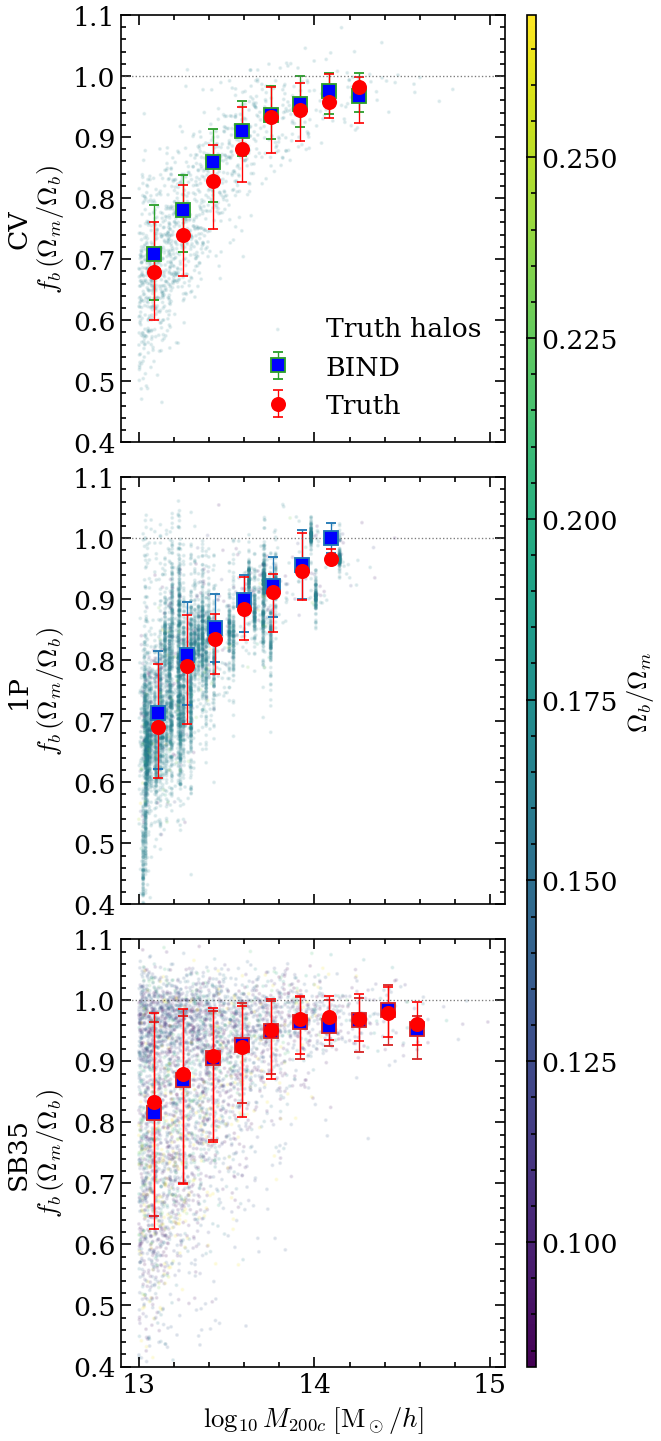

In [6]:
# ── Figure 1: normalised baryon fraction vs halo mass, by suite ─────────
import matplotlib.colors as mcolors


def _binned_stats(x, y, bins, min_count=15):
    """Median + 16th/84th percentile errorbars in x-bins; drop sparse bins."""
    if len(x) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])
    bm  = binned_statistic(x, y, statistic='median', bins=bins)
    blo = binned_statistic(x, y,
                           statistic=lambda v: np.percentile(v, 16), bins=bins)
    bhi = binned_statistic(x, y,
                           statistic=lambda v: np.percentile(v, 84), bins=bins)
    bn  = binned_statistic(x, y, statistic='count', bins=bins)
    xc  = 0.5 * (bm.bin_edges[:-1] + bm.bin_edges[1:])
    ok  = np.isfinite(bm.statistic) & (bn.statistic >= min_count)
    med    = bm.statistic[ok]
    err_lo = med - blo.statistic[ok]
    err_hi = bhi.statistic[ok] - med
    return xc[ok], med, err_lo, err_hi


def _f_b_cosmic(sub):
    """Per-halo Ω_b/Ω_m from the stored parameter columns."""
    omega_m = sub['p1'].to_numpy()
    omega_b = sub['p7'].to_numpy()
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(omega_m > 0, omega_b / omega_m, np.nan)


# Global colour normalisation across all suites
fb_cos_all = np.concatenate([
    _f_b_cosmic(obs_df[obs_df['suite'] == s]) for s in SUITES
])
fb_cos_all = fb_cos_all[np.isfinite(fb_cos_all)]
vmin, vmax = np.nanpercentile(fb_cos_all, [2, 98])
if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
    vmin, vmax = 0.12, 0.22
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = 'viridis'

K             = 'f_b_norm'
TRUTH_MARKER  = 'o'    # truth medians: circles
GEN_MARKER    = 's'    # gen medians:   squares

fig, axes = plt.subplots(3, 1, figsize=(5.5, 12),
                         sharex=True, constrained_layout=True)

for row, suite in enumerate(SUITES):
    ax      = axes[row]
    sub     = obs_df[obs_df['suite'] == suite]
    logm    = sub['logM'].to_numpy()
    t       = sub[f'truth_{K}'].to_numpy()
    g       = sub[f'gen_{K}'].to_numpy()
    f_b_cos = _f_b_cosmic(sub)

    mt = np.isfinite(logm) & np.isfinite(t) & np.isfinite(f_b_cos)
    mg = np.isfinite(logm) & np.isfinite(g) & np.isfinite(f_b_cos)

    # Halo cloud (truth, coloured by Ω_b/Ω_m)
    ax.scatter(logm[mt], t[mt], c=f_b_cos[mt], cmap=cmap, norm=norm,
               s=2, alpha=0.10,
               label='Truth halos' if row == 0 else None)

    if mt.sum() >= 30:
        x_lo = np.nanpercentile(logm[mt], 1)
        bins = np.linspace(x_lo, 15.0, 13)

        xt, tm, el_t, eh_t = _binned_stats(logm[mt], t[mt], bins)
        xg, gm, el_g, eh_g = _binned_stats(logm[mg], g[mg], bins)

        if len(xg):
            ax.errorbar(xg, gm, yerr=[el_g, eh_g],
                        fmt=GEN_MARKER, mfc='blue', mew=1.1, ms=8,
                        color=SUITE_COLORS[suite], linestyle='None',
                        capsize=3, elinewidth=0.8,
                        label='BIND' if row == 0 else None)
        if len(xt):
            ax.errorbar(xt, tm, yerr=[el_t, eh_t],
                        fmt=TRUTH_MARKER, color='red', ms=8, linestyle='None',
                        capsize=3, elinewidth=0.8,
                        label='Truth' if row == 0 else None)

    ax.axhline(1.0, color='0.35', lw=0.8, ls=':', alpha=0.8)
    ax.set_ylabel(SUITE_DISPLAY[suite] + '\n'
                  + r'$f_b\,(\Omega_m/\Omega_b)$')
    ax.set_ylim(0.4, 1.1)
    # ax.grid(axis='y', alpha=0.2)

axes[-1].set_xlabel(r'$\log_{10} M_{200c}\;[{\rm M}_\odot/h]$')
axes[0].legend(loc='best')

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), fraction=.1, pad=0.02,
                    aspect=150)
cbar.set_label(r'$\Omega_b/\Omega_m$')
# plt.tight_layout()

save_fig(fig, 'obs_baryon_fraction')
plt.show()


## Acts I–II — CV halo masses & scaling-relation fits

Loads truth + BIND2 patches across the usable CV simulations (26 boxes,
**1111 halos** with log M₂₀₀c ≥ 13), computes per-halo
M_dm / M_gas / M_star within R₂₀₀c, and fits the mean log–log scaling
relations. Uses the `fm_two_head_no_pmm` checkpoint (`MODEL_CV`, set above).

⚠️ **This exact halo set — in this exact order — is the one re-painted across
the 256 Sobol feedback designs in Act III.** The loader iterates
`sorted(CV dirs)` so the ordering matches the cube 1:1 (verified by a hard
assert when the cube loads).


In [7]:
from scipy import stats

CV_ROOT = SUITE_ROOT / 'CV'

# IMPORTANT — halo ordering.  The Sobol cube (loaded later, in "Act III") stores
# its 1111 halos in *lexicographic* CV-directory order (sim_0, sim_1, sim_10, ...),
# with sim_17 dropped (no `radii`) and sim_27 absent.  We MUST build the per-halo
# arrays here in that SAME order so every downstream array lines up 1:1 with the
# cube — otherwise the "track the same halos across 256 designs" premise silently
# tracks the WRONG halos.  Iterating sorted(CV_ROOT.iterdir()) with the same skip
# rules reproduces the cube ordering exactly (hard-asserted in Act III below).

# Per-halo aggregates accumulated across all usable CV sims, in cube order
all_halo_mass, all_radii_pix = [], []
all_Mdm,   all_Mgas,   all_Mstar   = [], [], []
all_Mdm_g, all_Mgas_g, all_Mstar_g = [], [], []
cv_sim_order = []

cv_dirs = sorted(d for d in CV_ROOT.iterdir() if d.is_dir())
print(f'Scanning {len(cv_dirs)} CV directories (model = {MODEL_CV}) ...')

for sim_dir in cv_dirs:
    sim_path = sim_dir / SNAP
    cat_path = sim_path / MASS_TAG / 'halo_catalog.npz'
    fm_path  = sim_path / 'full_maps.npz'
    gen_path = sim_path / MASS_TAG / MODEL_CV / 'generated_halos.npz'

    if not (cat_path.exists() and fm_path.exists() and gen_path.exists()):
        print(f'  {sim_dir.name}: missing files, skipping')
        continue

    cat = np.load(cat_path)
    if 'radii' not in cat.files:
        print(f'  {sim_dir.name}: unexpected catalog format (keys={cat.files}), skipping')
        continue

    fm     = np.load(fm_path)
    gen_np = np.load(gen_path)['generated']                     # (N, 3, 128, 128)
    truth  = fm['truth_maps']

    cen_pix = centers_to_pixels(cat['centers'])
    r_pix   = cat['radii'] / KPC_PER_PIX
    n       = len(cen_pix)

    Mdm   = np.empty(n);   Mgas   = np.empty(n);   Mstar   = np.empty(n)
    Mdm_g = np.empty(n);   Mgas_g = np.empty(n);   Mstar_g = np.empty(n)
    for i, (cx, cy) in enumerate(cen_pix):
        r = float(r_pix[i])
        Mdm[i]    = aperture_sum_raw(extract_patch(truth[0], int(cx), int(cy)), r)
        Mgas[i]   = aperture_sum_raw(extract_patch(truth[1], int(cx), int(cy)), r)
        Mstar[i]  = aperture_sum_raw(extract_patch(truth[2], int(cx), int(cy)), r)
        Mdm_g[i]   = aperture_sum_raw(gen_np[i, 0], r)
        Mgas_g[i]  = aperture_sum_raw(gen_np[i, 1], r)
        Mstar_g[i] = aperture_sum_raw(gen_np[i, 2], r)

    cv_sim_order.append(sim_dir.name)
    all_halo_mass.append(cat['masses'])
    all_radii_pix.append(r_pix)
    all_Mdm.append(Mdm);     all_Mgas.append(Mgas);     all_Mstar.append(Mstar)
    all_Mdm_g.append(Mdm_g); all_Mgas_g.append(Mgas_g); all_Mstar_g.append(Mstar_g)

    print(f'  {sim_dir.name:>7s}: {n:4d} halos  '
          f'R200c {r_pix.min():.1f}-{r_pix.max():.1f} px')

halo_mass = np.concatenate(all_halo_mass)
radii_pix = np.concatenate(all_radii_pix)
Mdm   = np.concatenate(all_Mdm);   Mgas   = np.concatenate(all_Mgas);   Mstar   = np.concatenate(all_Mstar)
Mdm_g = np.concatenate(all_Mdm_g); Mgas_g = np.concatenate(all_Mgas_g); Mstar_g = np.concatenate(all_Mstar_g)
Mbaryon   = Mgas   + Mstar
Mbaryon_g = Mgas_g + Mstar_g

print(f'\nPixel scale : {KPC_PER_PIX:.2f} kpc/h per px')
print(f'Usable CV sims : {len(cv_sim_order)}  ({", ".join(cv_sim_order)})')
print(f'Total halos : {len(halo_mass)}  (across {len(cv_sim_order)} sims)')
print(f'R200c range : {radii_pix.min():.1f} - {radii_pix.max():.1f} px')


Scanning 27 CV directories (model = fm_two_head_no_pmm) ...


    sim_0:   45 halos  R200c 7.2-21.4 px


    sim_1:   51 halos  R200c 7.2-20.3 px


   sim_10:   35 halos  R200c 7.2-20.8 px


   sim_11:   47 halos  R200c 7.2-18.5 px


...

    sim_5:   45 halos  R200c 7.2-18.2 px


    sim_6:   31 halos  R200c 7.2-22.3 px


    sim_7:   34 halos  R200c 7.3-21.2 px


    sim_8:   51 halos  R200c 7.2-16.2 px


    sim_9:   47 halos  R200c 7.2-20.3 px

Pixel scale : 48.83 kpc/h per px
Usable CV sims : 26  (sim_0, sim_1, sim_10, sim_11, sim_12, sim_13, sim_14, sim_15, sim_16, sim_18, sim_19, sim_2, sim_20, sim_21, sim_22, sim_23, sim_24, sim_25, sim_26, sim_3, sim_4, sim_5, sim_6, sim_7, sim_8, sim_9)
Total halos : 1111  (across 26 sims)
R200c range : 7.2 - 28.3 px


In [8]:
# ── fit log–log mean scaling relations and tabulate slope/scatter ────────
def fit_mean_relation(x, y, min_val=1.0):
    """OLS fit log10(y) = α·log10(x) + β. Returns (α, β, σ, mask, residual)."""
    mask = (x > min_val) & (y > min_val) & np.isfinite(x) & np.isfinite(y)
    lx, ly = np.log10(x[mask]), np.log10(y[mask])
    slope, intercept, *_ = stats.linregress(lx, ly)
    resid_m = ly - (slope * lx + intercept)
    resid_full = np.full(len(x), np.nan)
    resid_full[mask] = resid_m
    return slope, intercept, resid_m.std(), mask, resid_full


# (x_truth, y_truth, x_gen, y_gen, xlabel, ylabel)
RELATION_DEFS = {
    'Mgas–Mstar': (Mstar,     Mgas,     Mstar_g,   Mgas_g,
                   r'$M_\star$',         r'$M_\mathrm{gas}$'),
    'Mdm–Mstar':  (Mstar,     Mdm,      Mstar_g,   Mdm_g,
                   r'$M_\star$',         r'$M_\mathrm{dm}$'),
    'SHMR':       (halo_mass, Mstar,    halo_mass, Mstar_g,
                   r'$M_\mathrm{200c}$', r'$M_\star$'),
    'GasFrac':    (halo_mass, Mgas,     halo_mass, Mgas_g,
                   r'$M_\mathrm{200c}$', r'$M_\mathrm{gas}$'),
    'BaryonFrac': (halo_mass, Mbaryon,  halo_mass, Mbaryon_g,
                   r'$M_\mathrm{200c}$', r'$M_\mathrm{baryon}$'),
}

fits_t, fits_g = {}, {}
print(f"{'Relation':>14s}   {'truth α':>8s} {'truth σ':>8s}   "
      f"{'gen α':>8s} {'gen σ':>8s}")
for key, (xt, yt, xg, yg, xl, yl) in RELATION_DEFS.items():
    at, bt, st, mt, rt = fit_mean_relation(xt, yt)
    ag, bg, sg, mg, rg = fit_mean_relation(xg, yg)
    fits_t[key] = dict(alpha=at, beta=bt, scatter=st, mask=mt, resid=rt,
                       x=xt, y=yt, xlabel=xl, ylabel=yl)
    fits_g[key] = dict(alpha=ag, beta=bg, scatter=sg, mask=mg, resid=rg,
                       x=xg, y=yg, xlabel=xl, ylabel=yl)
    print(f'  {key:>14s}   {at:+.3f}   {st:.3f}     {ag:+.3f}   {sg:.3f}')


      Relation    truth α  truth σ      gen α    gen σ
      Mgas–Mstar   +1.167   0.114     +1.142   0.107
       Mdm–Mstar   +0.968   0.079     +0.969   0.075
            SHMR   +0.958   0.124     +0.958   0.124
         GasFrac   +1.195   0.129     +1.165   0.127
      BaryonFrac   +1.175   0.125     +1.146   0.124


## Figure 2 — Per-relation scaling fits

Each relation is modelled as a log–log power law fitted by ordinary least squares (OLS):

$$\log_{10} y_i = \alpha \log_{10} x_i + \beta + r_i$$

The OLS estimators minimise $\sum_i r_i^2$, giving slope $\hat\alpha$ and intercept $\hat\beta$.

**Per-halo residual** (used to colour the scatter points):

$$r_i = \log_{10} y_i - \bigl(\hat\alpha\,\log_{10} x_i + \hat\beta\bigr)$$

**Intrinsic scatter** (standard deviation of residuals, reported in each panel):

$$\sigma = \sqrt{\frac{1}{N}\sum_{i=1}^{N} r_i^2}$$

The grey band shows $\hat\alpha\,\log_{10} x + \hat\beta \pm \sigma$.

**Relations plotted** (all masses in $\mathrm{M}_\odot\,h^{-1}$, measured within $R_{200c}$):

| Panel | $x$ | $y$ |
|-------|-----|-----|
| $M_{\rm gas}$–$M_\star$ | $M_\star$ | $M_{\rm gas}$ |
| $M_{\rm DM}$–$M_\star$  | $M_\star$ | $M_{\rm DM}$  |
| SHMR                    | $M_{200c}$ (DMO) | $M_\star$ |
| Baryon fraction         | $M_{200c}$ (DMO) | $M_{\rm gas}+M_\star$ |

Colour scale: $r_i$ clipped to $\pm 2\sigma_{\rm max}$ (shared across all panels and both rows).


  wrote paper_figures/scaling_fits.pdf


  wrote paper_figures/scaling_fits.png


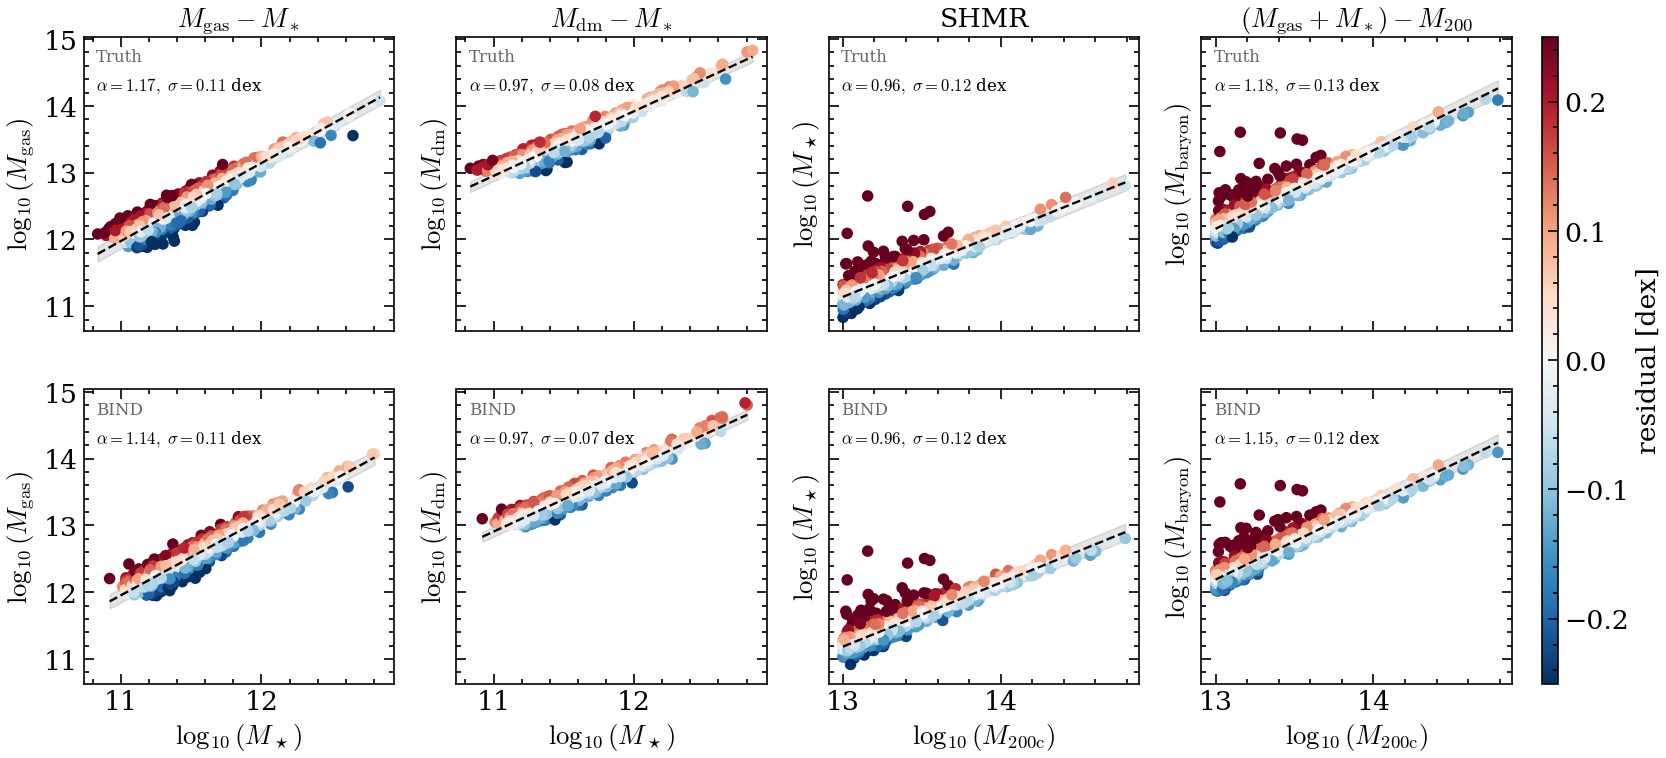

In [9]:
# ── Figure 2: per-relation scaling fits, residual-coloured ───────────────
# GasFrac dropped (degenerate with BaryonFrac)
REL_KEYS = [k for k in RELATION_DEFS if k != 'GasFrac']
n_rel = len(REL_KEYS)
titles = [r'$M_{\rm gas} - M_*$', r'$M_{\rm dm} - M_*$', r'SHMR', r'$(M_{\rm gas} + M_*) - M_{200}$']

# Global residual colour range: ±2σ across all relations & both rows
all_scatters = [fits_t[k]['scatter'] for k in REL_KEYS] + \
               [fits_g[k]['scatter'] for k in REL_KEYS]
global_clim = 2.0 * max(all_scatters)
RESID_NORM = mcolors.Normalize(vmin=-global_clim, vmax=global_clim)
RESID_CMAP = 'RdBu_r'

fig, axes = plt.subplots(2, n_rel, figsize=(16, 7),
                         sharex='col', sharey=True)

row_labels = ['Truth', 'BIND']
row_fits   = [fits_t, fits_g]

for row, (label, row_fd) in enumerate(zip(row_labels, row_fits)):
    for col, key in enumerate(REL_KEYS):
        ax = axes[row, col]
        fd = row_fd[key]
        m  = fd['mask']
        lx = np.log10(fd['x'][m])
        ly = np.log10(fd['y'][m])
        r  = fd['resid'][m]
        a, b, s = fd['alpha'], fd['beta'], fd['scatter']

        ax.scatter(lx, ly, c=r, cmap=RESID_CMAP, norm=RESID_NORM,
                   s=35, zorder=3)

        lx_line = np.linspace(lx.min(), lx.max(), 100)
        ax.plot(lx_line, a * lx_line + b, 'k--', lw=1.4, zorder=4)
        ax.fill_between(lx_line,
                        a * lx_line + b - s, a * lx_line + b + s,
                        color='k', alpha=0.10, zorder=2)

        if row == 0:
            ax.set_title(titles[col])
        if row == 1:
            ax.set_xlabel(r'$\log_{10}($' + fd['xlabel'] + r'$)$')
        ax.set_ylabel(r'$\log_{10}($' + fd['ylabel'] + r'$)$')
        if col > 0:
            ax.tick_params(axis='y', labelleft=False)

        ax.text(0.04, 0.96, label,
                transform=ax.transAxes, va='top',
                color='0.4', style='normal')
        ax.text(0.04, 0.87, fr'$\alpha={a:.2f},\ \sigma={s:.2f}$ dex',
                transform=ax.transAxes, va='top',
                bbox=dict(fc='white', ec='none', alpha=0.7))

# Single shared colorbar spanning both rows on the right
# axes.ravel().tolist() gives a flat list, required by fig.colorbar
sm = plt.cm.ScalarMappable(norm=RESID_NORM, cmap=RESID_CMAP)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), fraction=0.02, pad=0.02, aspect=40)
cbar.set_label('residual [dex]')

# plt.tight_layout()

save_fig(fig, 'scaling_fits')
plt.show()

## Figure 3 — Cross-relation residual corner plot

Starting from the per-halo residual vectors from Figure 2, each halo $i$ carries a residual for every relation $k$:

$$\mathbf{r}_i = \bigl(r_{M_{\rm gas}-M_\star},\; r_{M_{\rm dm}-M_\star},\; r_{\rm SHMR},\; r_{(M_{\rm gas}+M_\star)-M_{200}}\bigr)_i$$

**Tail classification** (by the *column* relation $j$):

$$\text{high tail}: \quad r_{i,j} > +\sigma_j \qquad \text{low tail}: \quad r_{i,j} < -\sigma_j$$

where $\sigma_j$ is the scatter of relation $j$ (from Figure 2).

**2D KDE** for each classified subset $(x = r_{i,j},\; y = r_{i,k})$, using a Gaussian kernel with Scott's bandwidth rule:

$$h = n^{-1/(d+4)}\,\hat\sigma, \qquad d = 2$$

**Contour levels** enclose fractions $p \in \{68.27\%,\;95.45\%,\;99.73\%\}$ of the distribution (corresponding to $1\sigma / 2\sigma / 3\sigma$ of a 2D Gaussian):

$$\int_{\hat{f}(\mathbf{x}) \ge \lambda_p} \hat{f}(\mathbf{x})\,d\mathbf{x} = p$$

Solid contours = Truth; dotted contours = BIND. Red = over-dense tail ($r > +\sigma$); blue = under-dense tail ($r < -\sigma$). Diagonal panels show 1D histograms of the classified halos.


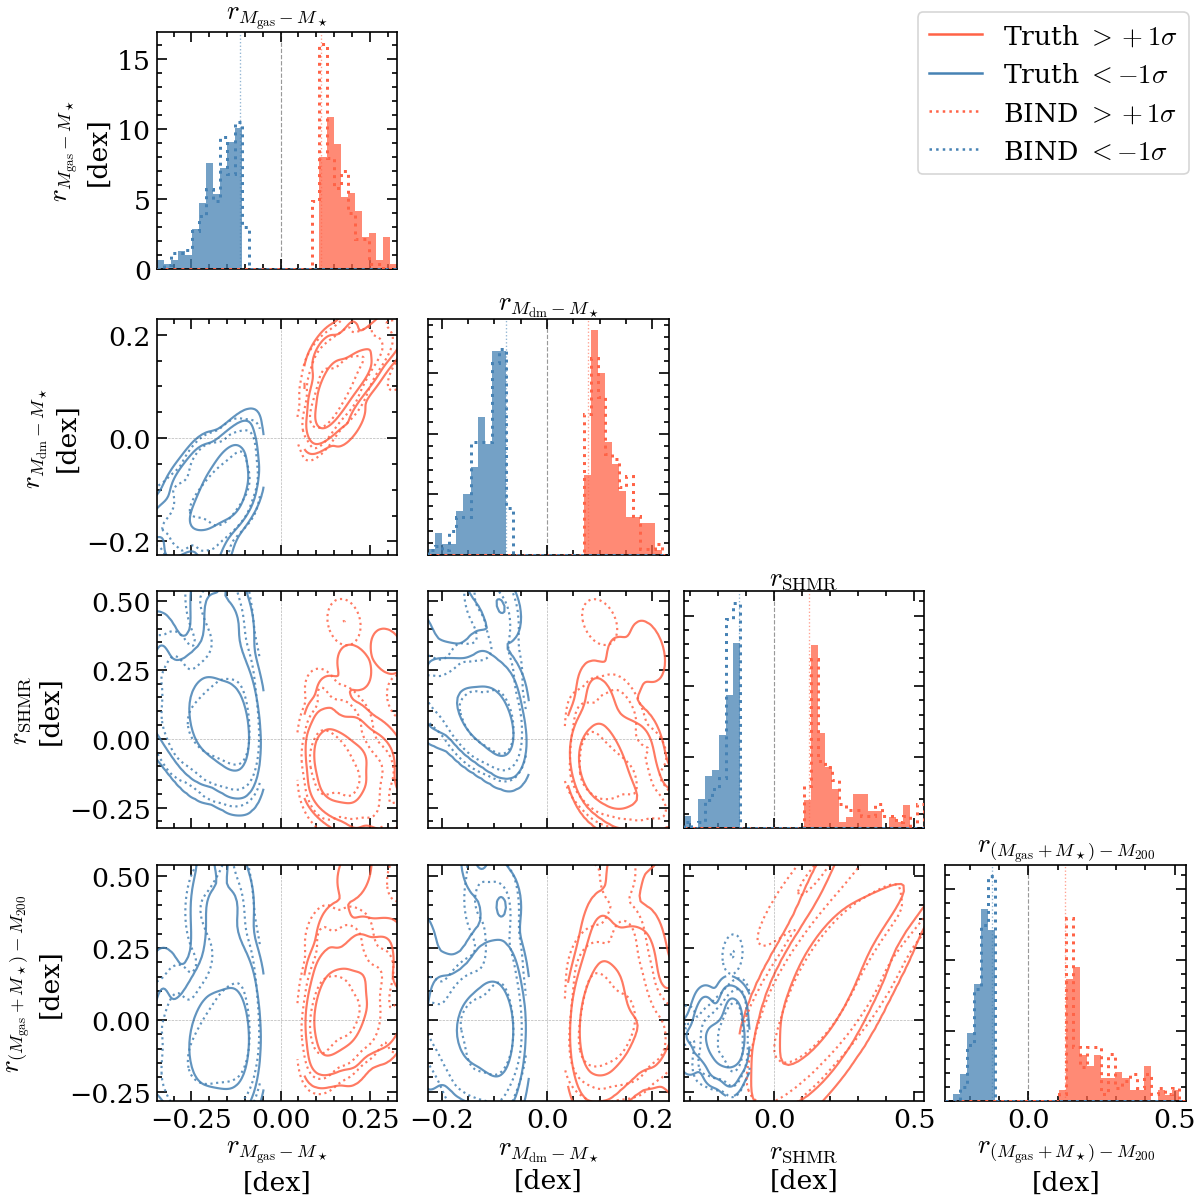

In [10]:
# ── Figure 3: cross-relation residual corner plot ────────────────────────
# Column j defines the ±1σ classification for that panel. Solid contours =
# Truth, dotted = Generated; levels enclose 1σ / 2σ / 3σ of each subset.
# `GasFrac` is dropped (degenerate with `BaryonFrac`).
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D

all_keys = [k for k in RELATION_DEFS if k != 'GasFrac']
N_rel    = len(all_keys)

# halos valid in ALL retained relations for both truth & generated
both_mask = np.ones(len(halo_mass), dtype=bool)
for k in all_keys:
    both_mask &= fits_t[k]['mask'] & fits_g[k]['mask']

R_t   = np.stack([fits_t[k]['resid'][both_mask] for k in all_keys], axis=1)
R_g   = np.stack([fits_g[k]['resid'][both_mask] for k in all_keys], axis=1)
sig_t = np.array([fits_t[k]['scatter'] for k in all_keys])
sig_g = np.array([fits_g[k]['scatter'] for k in all_keys])

short_labels = {
    'Mgas–Mstar': r'$r_{M_{\rm gas}-M_\star}$',
    'Mdm–Mstar':  r'$r_{M_{\rm dm}-M_\star}$',
    'SHMR':       r'$r_{\rm SHMR}$',
    'BaryonFrac': r'$r_{(M_{\rm gas}+M_\star)-M_{200}}$',
}
slabels = [short_labels.get(k, k) for k in all_keys]

# Per-relation axis limits: 1–99th pct across truth+gen, with 15% padding
var_range = []
for k_idx in range(N_rel):
    vals = np.concatenate([R_t[:, k_idx], R_g[:, k_idx]])
    lo, hi = np.nanpercentile(vals, [1, 99])
    pad = 0.15 * (hi - lo)
    var_range.append((lo - pad, hi + pad))

_SIGMA_FRACS = [0.6827, 0.9545, 0.9973]   # 1σ / 2σ / 3σ enclosures in 2D


def _sigma_levels(z):
    """KDE density thresholds enclosing 1σ/2σ/3σ of the distribution."""
    z_sorted = np.sort(z.ravel())[::-1]
    cumfrac  = np.cumsum(z_sorted) / z_sorted.sum()
    levels   = []
    for frac in _SIGMA_FRACS:
        idx = np.searchsorted(cumfrac, frac)
        levels.append(float(z_sorted[min(idx, len(z_sorted) - 1)]))
    return sorted(set(levels))


def _kde_contour(ax, x, y, color, linestyle='-', lw=1.3, alpha=0.85):
    if len(x) < 10:
        return
    dx, dy = x.max() - x.min(), y.max() - y.min()
    if dx < 1e-10 or dy < 1e-10:
        return
    pad = 0.20
    kde = gaussian_kde(np.vstack([x, y]), bw_method='scott')
    xg, yg = np.mgrid[x.min() - pad * dx : x.max() + pad * dx : 100j,
                      y.min() - pad * dy : y.max() + pad * dy : 100j]
    z      = kde(np.vstack([xg.ravel(), yg.ravel()])).reshape(xg.shape)
    levels = _sigma_levels(z)
    if levels:
        ax.contour(xg, yg, z, levels=levels, colors=[color],
                   alpha=alpha, linewidths=lw, linestyles=linestyle)


fig, axes = plt.subplots(N_rel, N_rel, figsize=(10, 10),
                         constrained_layout=True)

for i in range(N_rel):
    for j in range(N_rel):
        ax = axes[i, j]
        if j > i:
            ax.set_visible(False)
            continue

        # Tail classification by the column-j relation
        high_t = R_t[:, j] >  sig_t[j]
        low_t  = R_t[:, j] < -sig_t[j]
        high_g = R_g[:, j] >  sig_g[j]
        low_g  = R_g[:, j] < -sig_g[j]

        if i == j:
            lo, hi = var_range[i]
            bins = np.linspace(lo, hi, 35)
            ax.hist(R_t[high_t, i], bins=bins, color='tomato',    density=True,
                    alpha=0.75, zorder=2)
            ax.hist(R_t[low_t,  i], bins=bins, color='steelblue', density=True,
                    alpha=0.75, zorder=2)
            ax.hist(R_g[high_g, i], bins=bins, color='tomato',    density=True,
                    histtype='step', linestyle=':', lw=1.8, zorder=3)
            ax.hist(R_g[low_g,  i], bins=bins, color='steelblue', density=True,
                    histtype='step', linestyle=':', lw=1.8, zorder=3)
            ax.axvline( sig_t[i], c='tomato',    lw=0.8, ls=':', alpha=0.6)
            ax.axvline(-sig_t[i], c='steelblue', lw=0.8, ls=':', alpha=0.6)
            ax.axvline(0,         c='k',         lw=0.7, ls='--', alpha=0.4)
            ax.set_title(slabels[i], pad=2)
        else:
            _kde_contour(ax, R_t[high_t, j], R_t[high_t, i], 'tomato',    '-')
            _kde_contour(ax, R_t[low_t,  j], R_t[low_t,  i], 'steelblue', '-')
            _kde_contour(ax, R_g[high_g, j], R_g[high_g, i], 'tomato',    ':')
            _kde_contour(ax, R_g[low_g,  j], R_g[low_g,  i], 'steelblue', ':')
            ax.axhline(0, c='k', lw=0.4, ls='--', alpha=0.3)
            ax.axvline(0, c='k', lw=0.4, ls='--', alpha=0.3)

        ax.set_xlim(var_range[j])
        if i != j:
            ax.set_ylim(var_range[i])

        if j > 0:
            ax.set_yticklabels([])
        else:
            ax.set_ylabel(slabels[i] + '\n[dex]')
        if i < N_rel - 1:
            ax.set_xticklabels([])
        else:
            ax.set_xlabel(slabels[j] + '\n[dex]')

legend_elements = [
    Line2D([0], [0], color='tomato',    lw=1.5, ls='-',  label=r'Truth $>+1\sigma$'),
    Line2D([0], [0], color='steelblue', lw=1.5, ls='-',  label=r'Truth $<-1\sigma$'),
    Line2D([0], [0], color='tomato',    lw=1.5, ls=':',  label=r'BIND $>+1\sigma$'),
    Line2D([0], [0], color='steelblue', lw=1.5, ls=':',  label=r'BIND $<-1\sigma$'),
]
fig.legend(handles=legend_elements, loc='upper right', frameon=True)
plt.savefig(FIG_DIR / 'residual_corner_plot.pdf')
plt.show()


## Act III — The controlled feedback experiment

We now exploit BIND2's defining capability. The **exact same 1111 CV halos** from
Acts I–II are re-painted under a **256-point Sobol design in the 30
astrophysical (feedback) parameters**, with cosmology fixed at the CV fiducial and
**common random noise** (the per-halo generator seed is shared across designs).
Holding the halos — and hence cosmic variance and DMO structure — fixed means
every change below is a *pure feedback response*.

The cube lives on ceph (`sobol_ss_cv/`): for each design and each halo it stores
the gas/thermo observables and the per-halo power suppression. We load it here and
**assert** that its halos are the same halos, in the same order, as the CV
scaling-relation set built above — the alignment the whole experiment rests on.


In [11]:
# ── load the Sobol feedback cube (the controlled experiment) ──────────
from scipy.stats import spearmanr

SOBOL_ROOT = Path('/mnt/home/mlee1/ceph/sobol_ss_cv')
_cube  = np.load(SOBOL_ROOT / 'cube.npz',          allow_pickle=True)
_extra = np.load(SOBOL_ROOT / 'pk_supp_extra.npz')

OBS_NAMES   = [str(s) for s in _cube['obs_names']]      # Y200,T,S,P,f_gas,...
ASTRO_NAMES = [str(s) for s in _cube['astro_names']]    # 30 feedback knobs
D_norm      = _cube['design_norm'].astype(np.float64)   # (256, 30) in [0, 1]
n_design    = _cube['obs'].shape[0]                      # 256 designs
N_HALO      = _cube['obs'].shape[1]                      # 1111 halos

# per-halo suppression P_hydro/P_DMO at several scales  (design x halo)
SUPP = {
    r'$k=5\,h\,{\rm Mpc}^{-1}$':  _extra['supp_k5'].astype(np.float64),
    r'$k=10\,h\,{\rm Mpc}^{-1}$': _cube['obs'][:, :, OBS_NAMES.index('supp_k10')].astype(np.float64),
    r'band-avg':                  _extra['supp_band'].astype(np.float64),
}

# Alignment guard: the cube's halos MUST be the same halos, in the same order, as
# the CV scaling-relation arrays built above (the whole premise of Act III).  The
# CV loader iterates sorted(CV dirs), which reproduces the cube's lexicographic
# ordering exactly; this assert is the tripwire if that ever drifts.
assert N_HALO == len(halo_mass), (N_HALO, len(halo_mass))
assert np.allclose(_cube['M200'], halo_mass), \
    'cube/CV halo MASS misalignment — Act III would track the WRONG halos'

print(f'Sobol cube: {n_design} designs x {N_HALO} halos x {len(OBS_NAMES)} obs')
print(f'  feedback knobs varied : {len(ASTRO_NAMES)}  (cosmology fixed at CV fiducial)')
print(f'  halo set verified identical to the CV scaling-relation halos  ✓')


Sobol cube: 256 designs x 1111 halos x 8 obs
  feedback knobs varied : 30  (cosmology fixed at CV fiducial)
  halo set verified identical to the CV scaling-relation halos  ✓


### Figure 4 — Which feedback knobs move the gas-rich / gas-poor populations?

Halos are classified **once**, at the fiducial, by their BaryonFrac residual from
Figure 3 (gas-rich > +1σ, gas-poor < −1σ), then tracked through all 256
designs. For each design we record each tail's mean log f_gas and the **gap**
between them. Because the design is a quasi-random Sobol sequence we quantify
sensitivity with **mutual information** (k-NN) rather than a rank correlation —
assumption-free and sensitive to non-linear dependence. Large I_gap ⇒ the knob
controls the *separation* of the two populations; I_hi ≠ I_lo ⇒ it targets one
population.


Fiducial gas-rich :  107 halos  (BaryonFrac > +1σ)
Fiducial gas-poor :   85 halos  (BaryonFrac < -1σ)
(out of 1111 halos valid in all 4 relations)

Top 5 knobs by I(knob; gap):
  1. WindEnergyIn1e51erg                       I_hi=0.167  I_lo=0.124  I_gap=0.113
  2. IMFslope                                  I_hi=0.019  I_lo=0.065  I_gap=0.094
  3. SeedBlackHoleMass                         I_hi=0.042  I_lo=0.051  I_gap=0.065
  4. WindFreeTravelDensFac                     I_hi=0.046  I_lo=0.032  I_gap=0.058
  5. QuasarThreshold                           I_hi=0.000  I_lo=0.000  I_gap=0.049


  wrote paper_figures/tail_param_sensitivity_MI.pdf


  wrote paper_figures/tail_param_sensitivity_MI.png


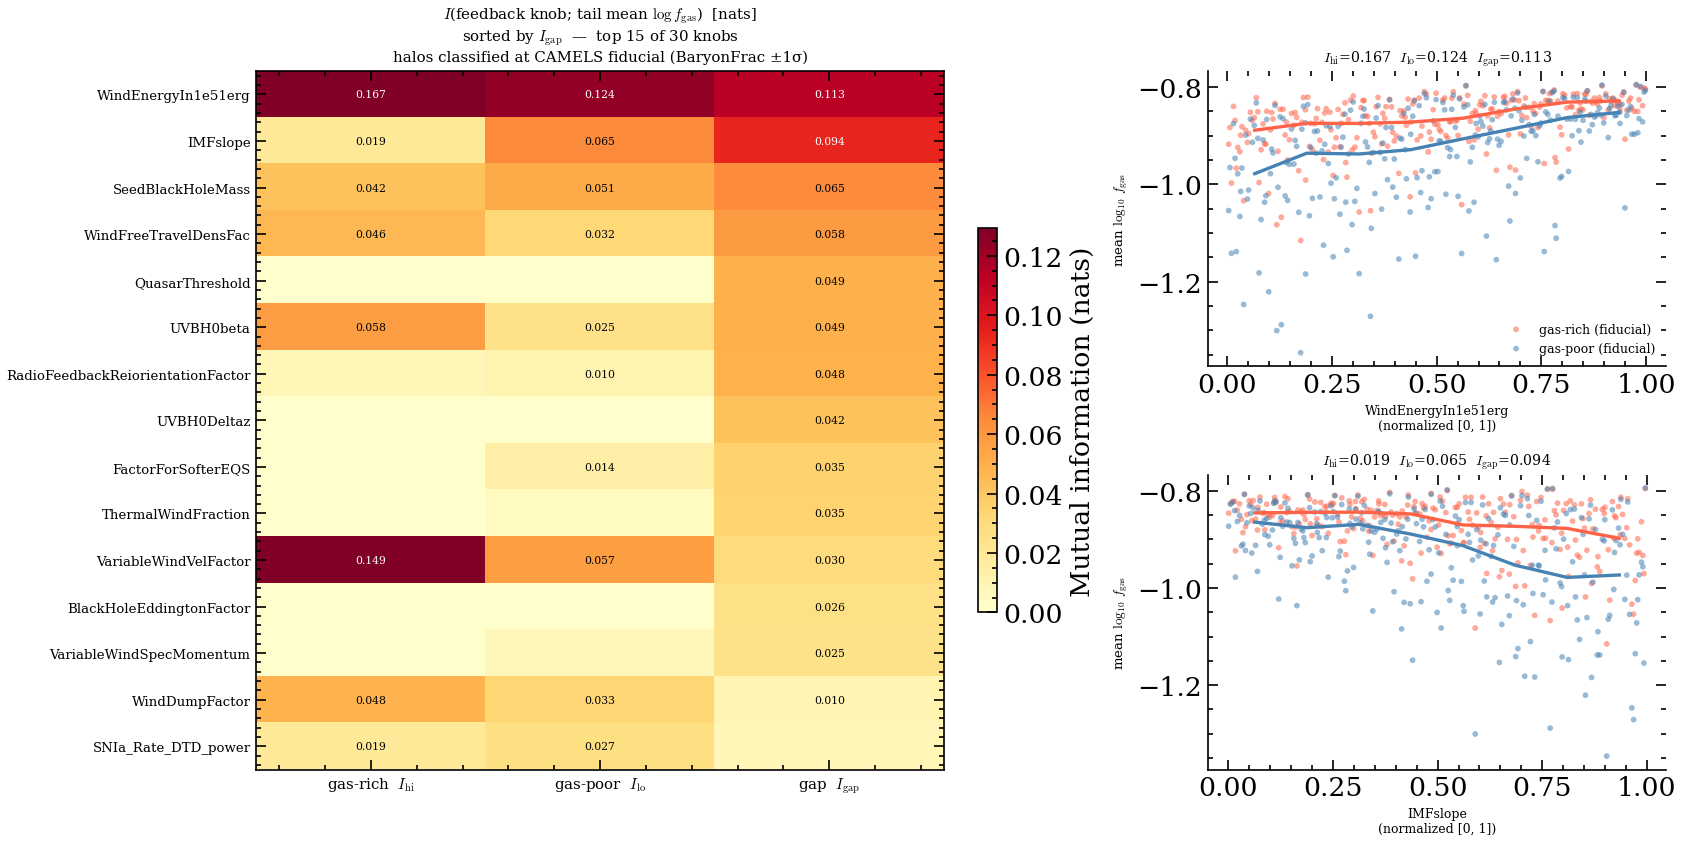

In [12]:
# ── Figure 3-ext: MI-based parameter sensitivity of fiducially-classified tails ─
# Halos are classified ONCE at the CAMELS fiducial using Figure 3's BaryonFrac
# column residuals.  The same halo indices are then tracked through all 256
# Sobol designs and mutual information (k-NN, sklearn) is used instead of
# Spearman ρ — MI is assumption-free and suited to Sobol quasi-random designs.
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import binned_statistic

# ── 1. Fiducial classification: red / blue from Fig 3 BaryonFrac column ──────
bf_col = all_keys.index('BaryonFrac')
hi_fid = R_t[:, bf_col] >  sig_t[bf_col]   # gas-rich (red in Fig 2/3)
lo_fid = R_t[:, bf_col] < -sig_t[bf_col]   # gas-poor (blue in Fig 2/3)

# Map from both_mask sub-indices back to global 1111-halo indices
global_idx = np.where(both_mask)[0]
hi_idx = global_idx[hi_fid]
lo_idx = global_idx[lo_fid]

# Per-halo boolean masks over the full N_HALO halo set (consumed by Fig 5).
# (Alignment of halo_mass with the cube is hard-asserted in the loader cell.)
hi_m = np.zeros(N_HALO, dtype=bool); hi_m[hi_idx] = True
lo_m = np.zeros(N_HALO, dtype=bool); lo_m[lo_idx] = True
print(f'Fiducial gas-rich : {len(hi_idx):4d} halos  (BaryonFrac > +1σ)')
print(f'Fiducial gas-poor : {len(lo_idx):4d} halos  (BaryonFrac < -1σ)')
print(f'(out of {both_mask.sum()} halos valid in all 4 relations)')

# ── 2. Per-design mean log f_gas for each fiducially-classified tail ──────────
f_gas_cube = _cube['obs'][:, :, OBS_NAMES.index('f_gas')].astype(np.float64)
lfg  = np.log10(np.clip(f_gas_cube, 1e-7, None))   # (256, 1111)
dhi  = np.nanmean(lfg[:, hi_idx], axis=1)           # (256,) gas-rich mean
dlo  = np.nanmean(lfg[:, lo_idx], axis=1)           # (256,) gas-poor mean
dgap = dhi - dlo                                    # (256,) separation

# ── 3. Mutual information: I(knob; tail statistic) for all 30 knobs ──────────
# mutual_info_regression takes the full (256, 30) design matrix at once
X_all  = D_norm   # (256, 30), normalized [0, 1]
mi_hi  = mutual_info_regression(X_all, dhi,  random_state=0, n_neighbors=5)
mi_lo  = mutual_info_regression(X_all, dlo,  random_state=0, n_neighbors=5)
mi_gap = mutual_info_regression(X_all, dgap, random_state=0, n_neighbors=5)

# Sort by MI for the gap — which knobs most inform the tail separation?
srt = np.argsort(-mi_gap)
TOP = 15
print('\nTop 5 knobs by I(knob; gap):')
for rank, pidx in enumerate(srt[:5]):
    print(f'  {rank+1}. {ASTRO_NAMES[pidx]:<40s}  '
          f'I_hi={mi_hi[pidx]:.3f}  I_lo={mi_lo[pidx]:.3f}  I_gap={mi_gap[pidx]:.3f}')

# ── 4. Figure ──────────────────────────────────────────────────────────────────
_vmax = np.percentile(np.concatenate([mi_hi, mi_lo, mi_gap]), 98)

fig = plt.figure(figsize=(14, 7), constrained_layout=True)
gs  = fig.add_gridspec(2, 2, width_ratios=[1.8, 1.2])
ax_heat = fig.add_subplot(gs[:, 0])
ax_p1   = fig.add_subplot(gs[0, 1])
ax_p2   = fig.add_subplot(gs[1, 1])

# ── A: MI heatmap ──────────────────────────────────────────────────────────────
heat = np.stack([mi_hi[srt[:TOP]], mi_lo[srt[:TOP]], mi_gap[srt[:TOP]]], axis=1)
im   = ax_heat.imshow(heat, cmap='YlOrRd', vmin=0, vmax=_vmax, aspect='auto')

ax_heat.set_xticks([0, 1, 2])
ax_heat.set_xticklabels(
    [r'gas-rich  $I_{\rm hi}$',
     r'gas-poor  $I_{\rm lo}$',
     r'gap  $I_{\rm gap}$'], fontsize=9)
ax_heat.set_yticks(range(TOP))
ax_heat.set_yticklabels([ASTRO_NAMES[i] for i in srt[:TOP]], fontsize=8)
ax_heat.set_title(
    r'$I$(feedback knob; tail mean $\log f_{\rm gas}$)  [nats]' + '\n'
    r'sorted by $I_{\rm gap}$  —  top 15 of 30 knobs' + '\n'
    'halos classified at CAMELS fiducial (BaryonFrac ±1σ)', fontsize=9)
fig.colorbar(im, ax=ax_heat, shrink=0.55, label='Mutual information (nats)', fraction=0.04)

for i, pidx in enumerate(srt[:TOP]):
    for j, mi in enumerate([mi_hi[pidx], mi_lo[pidx], mi_gap[pidx]]):
        if mi > 0.01:
            ax_heat.text(j, i, f'{mi:.3f}', ha='center', va='center',
                         fontsize=6.5,
                         color='white' if mi > 0.6 * _vmax else 'k')

# ── B & C: per-design scatter + running median for the top-2 gap knobs ────────
_C_HI = 'tomato'
_C_LO = 'steelblue'

for ax, pidx in [(ax_p1, srt[0]), (ax_p2, srt[1])]:
    pname = ASTRO_NAMES[pidx]
    x     = D_norm[:, pidx]

    ax.scatter(x, dhi, s=12, c=_C_HI, alpha=0.55, edgecolors='none',
               label='gas-rich (fiducial)', zorder=2)
    ax.scatter(x, dlo, s=12, c=_C_LO, alpha=0.55, edgecolors='none',
               label='gas-poor (fiducial)', zorder=2)

    bins = np.linspace(x.min(), x.max(), 9)
    for arr, c in [(dhi, _C_HI), (dlo, _C_LO)]:
        bm, be, _ = binned_statistic(x, arr, statistic='median', bins=bins)
        xc = 0.5 * (be[:-1] + be[1:])
        ok = np.isfinite(bm)
        ax.plot(xc[ok], bm[ok], '-', c=c, lw=2.0, zorder=4)

    ax.set_xlabel(f'{pname}\n(normalized [0, 1])', fontsize=7.5)
    ax.set_ylabel(r'mean $\log_{10}\, f_{\rm gas}$', fontsize=8)
    ax.set_title(fr'$I_{{\rm hi}}$={mi_hi[pidx]:.3f}  '
                 fr'$I_{{\rm lo}}$={mi_lo[pidx]:.3f}  '
                 fr'$I_{{\rm gap}}$={mi_gap[pidx]:.3f}', fontsize=8.5)
    if ax is ax_p1:
        ax.legend(fontsize=7.5, loc='best')
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)

save_fig(fig, 'tail_param_sensitivity_MI')
plt.show()


### Figure 5 — How the f_gas distributions of the two populations shift

The same top-2 knobs, but now the *full f_gas distribution* of each tail in
low / mid / high thirds of the knob value. A systematic relative shift means the
knob tilts the gas-rich and gas-poor populations with respect to each other.


  wrote paper_figures/tail_fgas_distribution_shift.pdf


  wrote paper_figures/tail_fgas_distribution_shift.png


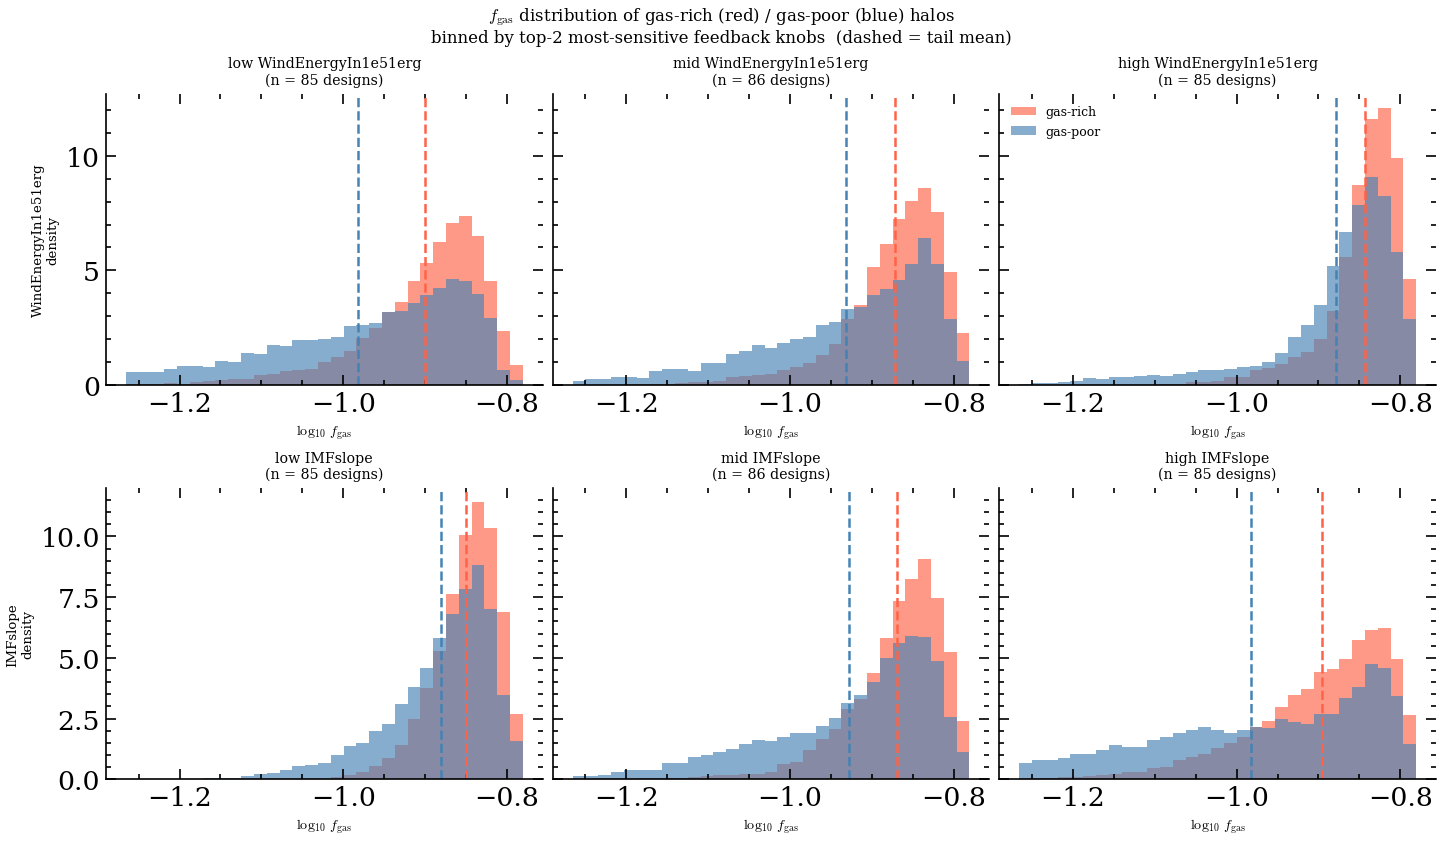

In [13]:
# ── Figure 3-ext (b): distribution shift — how the f_gas histogram of each
# tail moves as the top-2 sensitivity knobs vary ───────────────────────────
# Divide the 256 designs into low / mid / high thirds of the knob value.
# Each panel shows the f_gas distribution of gas-rich (red) and gas-poor
# (blue) halos at that slice.  A systematic shift = the knob tilts the two
# populations relative to each other.

fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey='row', constrained_layout=True)

lfg_all = lfg[:, hi_m | lo_m]   # combined range for shared bin edges

for row, pidx in enumerate([srt[0], srt[1]]):
    pname = ASTRO_NAMES[pidx]
    x     = D_norm[:, pidx]
    lo_t, hi_t = np.percentile(x, [33, 67])
    slices = [x <= lo_t, (x > lo_t) & (x <= hi_t), x > hi_t]
    slice_labels = [f'low {pname}', f'mid {pname}', f'high {pname}']

    # Shared bin edges for this row (cover full range across all 3 slices)
    vlo = np.nanpercentile(lfg_all[slices[0] | slices[1] | slices[2]], 1)
    vhi = np.nanpercentile(lfg_all[slices[0] | slices[1] | slices[2]], 99)
    bins_f = np.linspace(vlo, vhi, 32)

    for col, (des_mask, label) in enumerate(zip(slices, slice_labels)):
        ax = axes[row, col]
        hi_vals = lfg[des_mask][:, hi_m].ravel()
        lo_vals = lfg[des_mask][:, lo_m].ravel()

        ax.hist(hi_vals, bins=bins_f, color='tomato',    density=True,
                alpha=0.65, label='gas-rich')
        ax.hist(lo_vals, bins=bins_f, color='steelblue', density=True,
                alpha=0.65, label='gas-poor')

        # Mark the means
        ax.axvline(np.nanmean(hi_vals), color='tomato',    lw=1.5, ls='--')
        ax.axvline(np.nanmean(lo_vals), color='steelblue', lw=1.5, ls='--')

        ax.set_xlabel(r'$\log_{10}\, f_{\rm gas}$', fontsize=8.5)
        ax.set_title(f'{label}\n(n = {des_mask.sum()} designs)', fontsize=8.5)
        if col == 0:
            ax.set_ylabel(f'{pname}\ndensity', fontsize=8)
        if row == 0 and col == 2:
            ax.legend(fontsize=7.5)
        for sp in ('top', 'right'):
            ax.spines[sp].set_visible(False)

fig.suptitle(
    r'$f_{\rm gas}$ distribution of gas-rich (red) / gas-poor (blue) halos'
    '\nbinned by top-2 most-sensitive feedback knobs  '
    '(dashed = tail mean)',
    fontsize=10)

save_fig(fig, 'tail_fgas_distribution_shift')
plt.show()


## Act IV — From feedback to the matter power spectrum

### Figure 6 — Box-level suppression across the 256 designs

Pasting every design's re-painted halo patches back into the full 50 Mpc/h box
gives the total-matter suppression S(k)=P_BIND/P_DMO. The fan below shows all 256
designs coloured by the four knobs that most drive box S(k=3); the dashed curve is
the design-independent hydro-truth reference.


In [14]:
# ── Act IV: load the box-level matter-power suppression cache ────────
# tools/box_supp_sobol.py pastes each design's generated halo patches back into
# the full 50 Mpc/h DMO box (one composite per CV sim) and measures the total-
# matter suppression S(k)=P_BIND/P_DMO, sim-averaged.  Its halo blocks use the
# SAME cube order as above, so design index d here matches D_norm[d].
BOX_CACHE = CACHE_DIR / 'box_supp_sobol.npz' \
    if (CACHE_DIR / 'box_supp_sobol.npz').exists() \
    else Path('analysis_physics_cache/box_supp_sobol.npz')
_bx = np.load(BOX_CACHE)
k_box      = _bx['k_box']                       # (nk,)
S_true     = _bx['S_true'].astype(np.float64)   # (256, nk) sim-averaged box S(k)
S_truth    = _bx['S_truth'].astype(np.float64)  # (nk,) hydro-truth reference
n_dsg = S_true.shape[0]
print(f'box suppression: {n_dsg} designs x {len(k_box)} k-bins, '
      f'k in [{k_box.min():.2f}, {k_box.max():.0f}] h/Mpc')

# The box integrates over the whole halo population at fixed cosmology, so its
# role here is two-fold: (1) exhibit the real feedback-driven spread of S(k)
# across the 256 designs, and (2) verify that the per-halo emulator response
# tracks the cosmological box (the proxy check below), which licenses the
# per-halo (Act III) analysis.  S_massonly is also in the cache but not used here.


def _kidx(kt):
    return int(np.argmin(np.abs(k_box - kt)))


KW = [1.0, 3.0, 10.0]                            # weak-lensing-relevant scales
kix = {kt: _kidx(kt) for kt in KW}

# (1) cosmological spread at fixed cosmology: how far apart are the designs?
for kt in KW:
    col = S_true[:, kix[kt]]
    print(f'  S_box(k={kt:>4}): median={np.median(col):.3f}, '
          f'5-95% spread={np.percentile(col, 95) - np.percentile(col, 5):.3f}, '
          f'truth={S_truth[kix[kt]]:.3f}')

# (2) does the per-halo proxy track the box? mass-weighted per-halo supp at k=10
w = _cube['M200'].astype(np.float64)             # mass weighting (power ~ mass)
S_perhalo_k10 = SUPP[r'$k=10\,h\,{\rm Mpc}^{-1}$']    # (256, N_halo)
proxy = np.array([np.average(S_perhalo_k10[d][np.isfinite(S_perhalo_k10[d])],
                             weights=w[np.isfinite(S_perhalo_k10[d])])
                  for d in range(n_dsg)])
box_k10 = S_true[:, kix[10.0]]
rho_proxy, p_proxy = spearmanr(proxy, box_k10)
print(f'\nper-halo proxy vs box S(k=10): Spearman rho={rho_proxy:+.2f} '
      f'(p={p_proxy:.0e})  -> per-halo (Act III) analysis tracks the cosmological box')

# (3) Sobol-style first-order sensitivity of box suppression to the knobs.
#     Standardised OLS |beta| of S_box(k=3) on the 30 design knobs.
k_sens = 3.0
y_b = S_true[:, kix[k_sens]]
Xb = (D_norm - D_norm.mean(0)) / D_norm.std(0)
beta_box, *_ = np.linalg.lstsq(np.column_stack([Xb, np.ones(n_dsg)]),
                               (y_b - y_b.mean()) / y_b.std(), rcond=None)
beta_box = beta_box[:30]
box_drive = np.argsort(-np.abs(beta_box))
print(f'\nbox S(k={k_sens}) top drivers:',
      [f'{ASTRO_NAMES[i]} ({beta_box[i]:+.2f})' for i in box_drive[:4]])


box suppression: 256 designs x 724 k-bins, k in [0.15, 91] h/Mpc
  S_box(k= 1.0): median=1.009, 5-95% spread=0.018, truth=0.990
  S_box(k= 3.0): median=1.021, 5-95% spread=0.106, truth=0.958
  S_box(k=10.0): median=0.943, 5-95% spread=0.295, truth=0.809

per-halo proxy vs box S(k=10): Spearman rho=+1.00 (p=1e-322)  -> per-halo (Act III) analysis tracks the cosmological box

box S(k=3.0) top drivers: ['IMFslope (-0.51)', 'WindEnergyIn1e51erg (+0.36)', 'BlackHoleRadiativeEfficiency (+0.26)', 'RadioFeedbackReiorientationFactor (-0.24)']


  wrote paper_figures/box_suppression_design_fan.pdf


  wrote paper_figures/box_suppression_design_fan.png


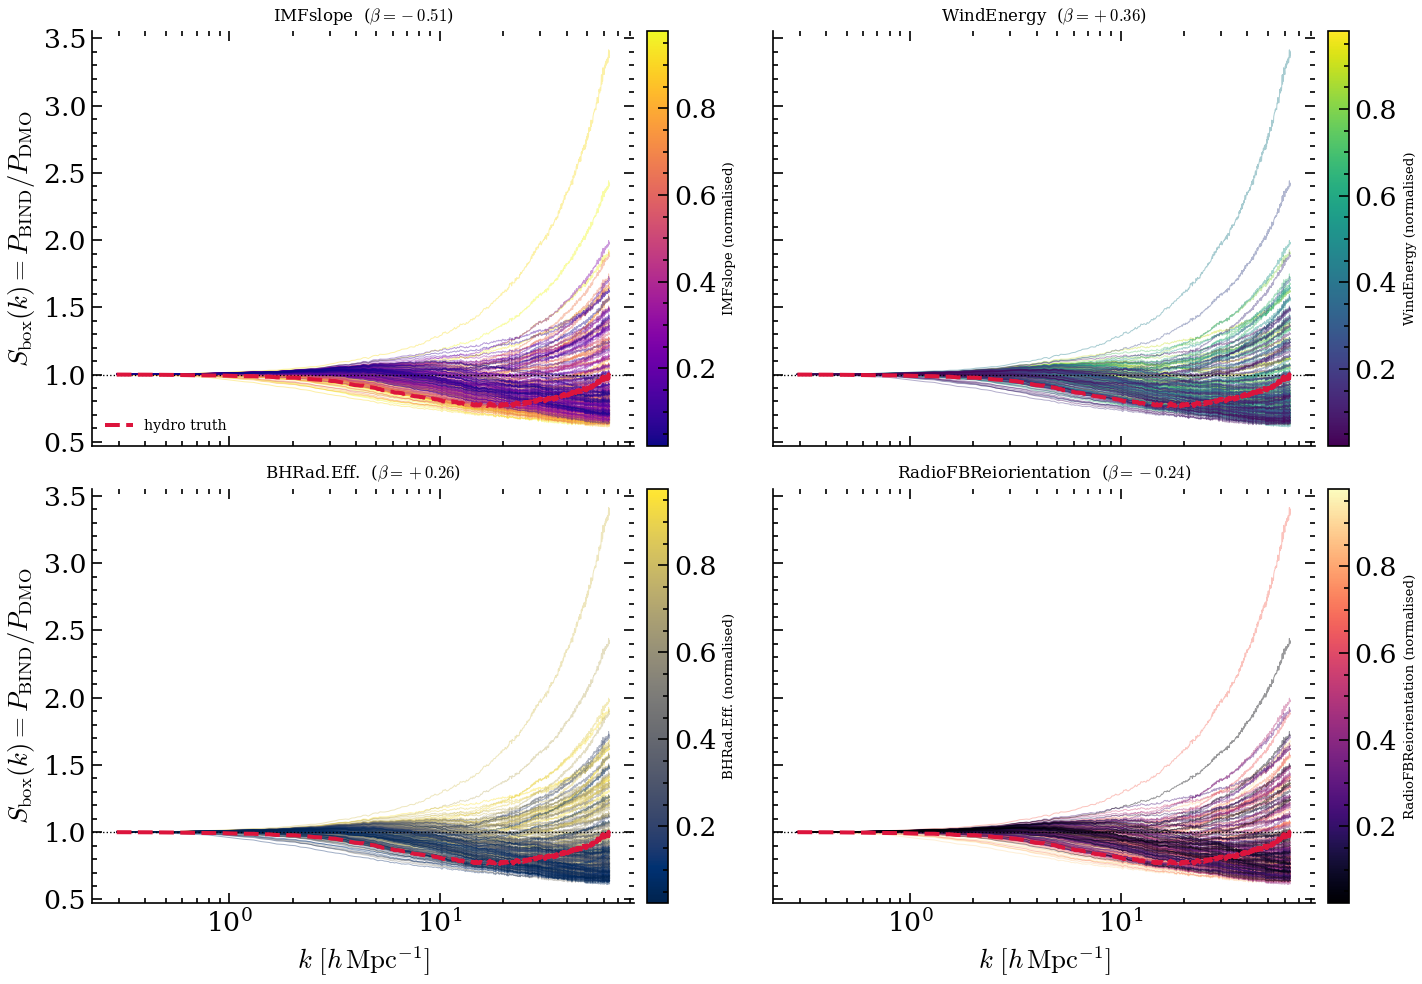

In [15]:
# ── Figure 6: design fan coloured by the top-4 box-level feedback drivers ─
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

kmask = (k_box >= 0.2) & (k_box <= 64.0)
kk = k_box[kmask]

# short, readable names for the parameter labels
def _short(name):
    return (name.replace('In1e51erg', '').replace('Factor', '')
                .replace('BlackHole', 'BH').replace('Radiative', 'Rad.')
                .replace('Reionization', 'Reion.').replace('Feedback', 'FB')
                .replace('Efficiency', 'Eff.').replace('Radio', 'Radio'))

top4_idx = box_drive[:4]
cmaps = [plt.cm.plasma, plt.cm.viridis, plt.cm.cividis, plt.cm.magma]

fig, axes = plt.subplots(2, 2, figsize=(12.0, 8.4), sharex=True, sharey=True)

for ax, idx, cm in zip(axes.flat, top4_idx, cmaps):
    vals = D_norm[:, idx]
    norm = Normalize(np.percentile(vals, 2), np.percentile(vals, 98))
    # draw highest-param first so the low end (usually most suppressed) sits on top
    for d in np.argsort(-vals):
        ax.plot(kk, S_true[d][kmask], color=cm(norm(vals[d])), lw=0.6, alpha=0.40)
    ax.plot(kk, S_truth[kmask], color='crimson', lw=2.4, ls='--',
            label='hydro truth', zorder=6)
    ax.axhline(1.0, color='k', lw=0.8, ls=':')
    ax.set_xscale('log')
    name = _short(ASTRO_NAMES[idx])
    beta = beta_box[idx]
    ax.set_title(f'{name}  ($\\beta={beta:+.2f}$)', fontsize=10)
    cb = fig.colorbar(ScalarMappable(norm=norm, cmap=cm), ax=ax, pad=0.02)
    cb.set_label(f'{name} (normalised)', fontsize=8)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

# shared axis labels
for ax in axes[1]:
    ax.set_xlabel(r'$k\ [h\,{\rm Mpc}^{-1}]$')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$S_{\rm box}(k)=P_{\rm BIND}/P_{\rm DMO}$')

axes.flat[0].legend(loc='lower left', fontsize=8.5)

fig.tight_layout()
save_fig(fig, 'box_suppression_design_fan')
plt.show()


### Figure 7 — One observable bridges per-halo gas content and the box P(k)

The synthesis. We collapse the controlled halo set to a single per-design number
— the **mean halo gas fraction** — and compare it against the real full-box
suppression. Two things tie the whole notebook together: **(A)** the *same*
feedback knobs drive both the per-halo gas content and the box-level P(k)
suppression, and **(B)** that one population observable predicts the box
suppression. This is exactly what the controlled, field-level setup buys: a clean
map from feedback → halo baryons → the cosmological matter power spectrum.


design-mean log f_gas vs box S(k=10): Spearman rho=+0.54 (p=1.4e-20)
shared top drivers: ['IMFslope', 'WindEnergy', 'VariableWindVel', 'BHRad.Eff.']


  wrote paper_figures/perhalo_box_synthesis.pdf


  wrote paper_figures/perhalo_box_synthesis.png


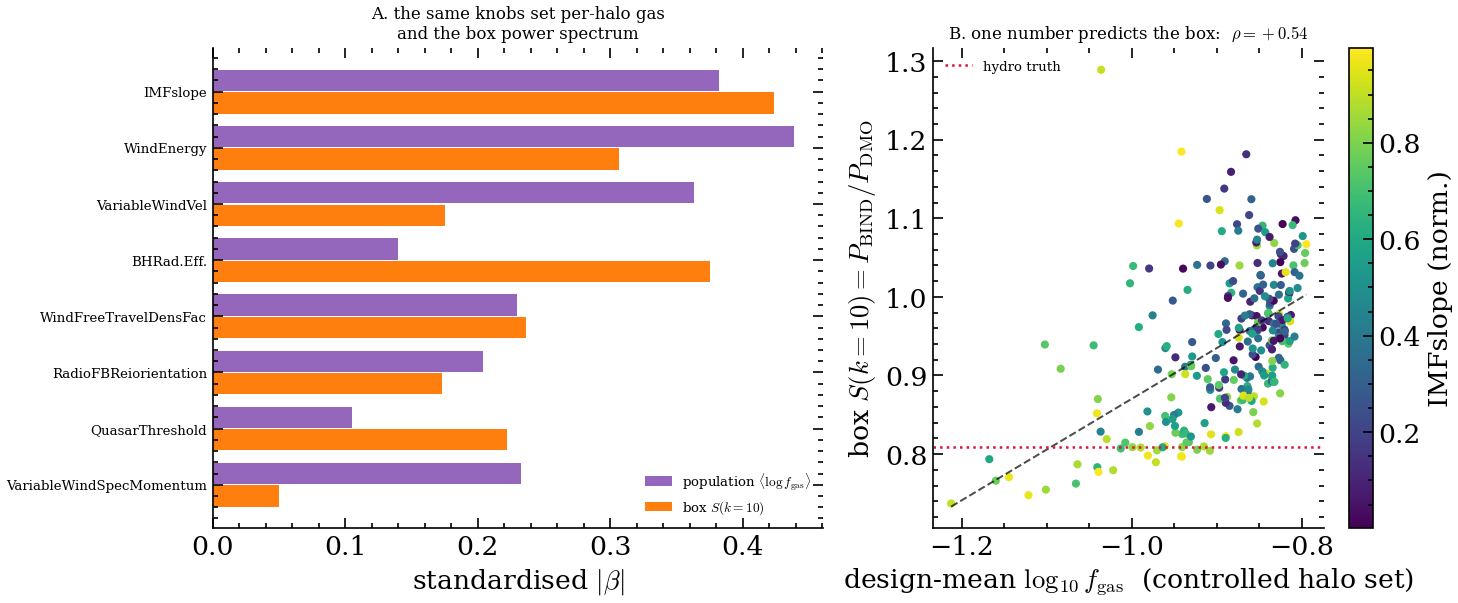

In [16]:
# ── Figure 7: one observable bridges per-halo gas content and the box P(k) ──
# Collapse the controlled halo set to a single per-design population observable —
# the mean halo gas fraction — and show (A) it shares its feedback drivers with the
# box suppression and (B) it predicts the box suppression.
fgas_pop = np.nanmean(lfg, axis=1)          # (256,) design-mean log f_gas
box_k10  = S_true[:, kix[10.0]]             # (256,) real full-box S(k=10)


def _std_betas(y):
    """Standardised-OLS coefficients of the 30 knobs on target y (returns beta)."""
    Xb = (D_norm - D_norm.mean(0)) / D_norm.std(0)
    b, *_ = np.linalg.lstsq(np.column_stack([Xb, np.ones(n_dsg)]),
                            (y - y.mean()) / y.std(), rcond=None)
    return b[:30]


b_fgas = _std_betas(fgas_pop)
b_box  = _std_betas(box_k10)
order  = np.argsort(-(np.abs(b_fgas) + np.abs(b_box)))[:8]
rho, pval = spearmanr(fgas_pop, box_k10)
print(f'design-mean log f_gas vs box S(k=10): Spearman rho={rho:+.2f} (p={pval:.1e})')
print('shared top drivers:', [_short(ASTRO_NAMES[i]) for i in order[:4]])

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.2),
                               gridspec_kw=dict(width_ratios=[1.25, 1.0]))

# Panel A — shared feedback drivers
yy = np.arange(len(order))
axL.barh(yy - 0.2, np.abs(b_fgas[order]), height=0.38,
         color='tab:purple', label=r'population $\langle\log f_{\rm gas}\rangle$')
axL.barh(yy + 0.2, np.abs(b_box[order]),  height=0.38,
         color='tab:orange', label=r'box $S(k{=}10)$')
axL.set_yticks(yy)
axL.set_yticklabels([_short(ASTRO_NAMES[i]) for i in order], fontsize=8)
axL.invert_yaxis()
axL.set_xlabel(r'standardised $|\beta|$')
axL.set_title('A. the same knobs set per-halo gas\nand the box power spectrum',
              fontsize=10)
axL.legend(fontsize=8, loc='lower right')
for sp in ('top', 'right'):
    axL.spines[sp].set_visible(False)

# Panel B — the population observable predicts the box suppression
sc = axR.scatter(fgas_pop, box_k10, c=D_norm[:, order[0]], cmap='viridis',
                 s=24, edgecolors='none')
m, c0 = np.polyfit(fgas_pop, box_k10, 1)
xs = np.linspace(fgas_pop.min(), fgas_pop.max(), 50)
axR.plot(xs, m * xs + c0, 'k--', lw=1.2, alpha=0.7)
axR.axhline(S_truth[kix[10.0]], color='crimson', lw=1.5, ls=':',
            label='hydro truth')
axR.set_xlabel(r'design-mean $\log_{10} f_{\rm gas}$  (controlled halo set)')
axR.set_ylabel(r'box $S(k{=}10)=P_{\rm BIND}/P_{\rm DMO}$')
axR.set_title(fr'B. one number predicts the box:  $\rho={rho:+.2f}$', fontsize=10)
axR.legend(fontsize=8, loc='upper left')
fig.colorbar(sc, ax=axR, label=_short(ASTRO_NAMES[order[0]]) + ' (norm.)')
for sp in ('top', 'right'):
    axR.spines[sp].set_visible(False)

save_fig(fig, 'perhalo_box_synthesis')
plt.show()
